In [104]:
#Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.tree import DecisionTreeRegressor 
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [76]:
#load dataset
df = pd.read_csv(r"C:\Users\dapan\OneDrive\Documents\New folder\Data Science\archive (1)\housing.csv")

In [78]:
#check first 5 rows of dataset
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [79]:
#Look at the shape of the dataset
df.shape

(20640, 10)

In [80]:
#Look at the datatypes of the dataset 
#Not needed since we have already looked at the dataset and know that all the datatypes are numerical.
#df_variable_type = fetch_ucirepo(id = 17)
#print(df_variable_type.variables)

In [81]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [82]:
#Check for null values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
#This was originally used to drop the null values, but I later dropped the only column that had null values.
#df = df.dropna()

In [83]:
#Drop the ocean_proximity column since it is categorical and we are only using numerical features for this project.
df_minus_ocean_proximity = df.drop(["ocean_proximity"], axis=1)

<Axes: >

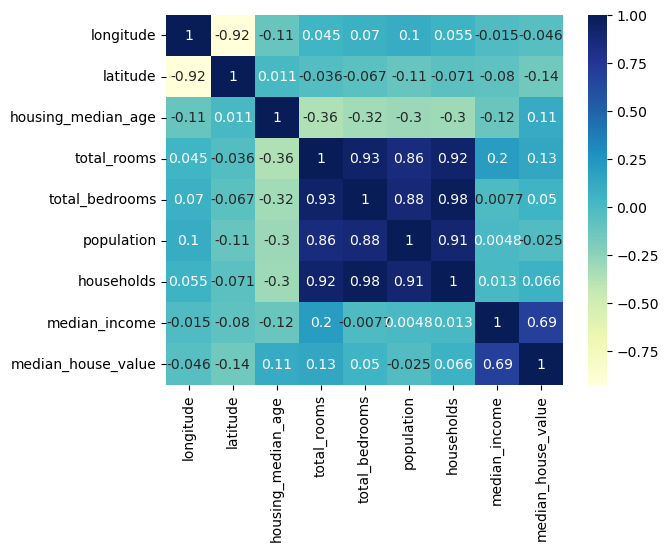

In [84]:
#Create a heatmap to visualize the correlation between the features and the target variable.
sns.heatmap(df_minus_ocean_proximity.corr(), annot = True, cmap = "YlGnBu")

In [85]:
#remove correlated features
df_minus_corr_variables = df.drop(['total_bedrooms', 'population', 'households', 'ocean_proximity'], axis=1, errors='ignore')

<Axes: >

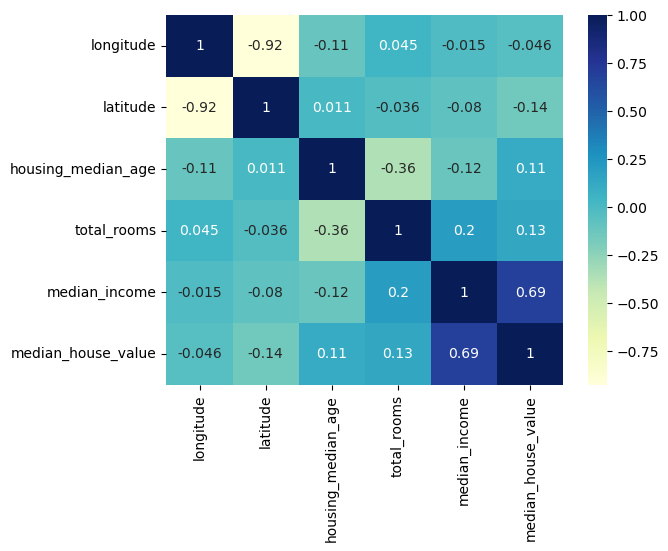

In [86]:
#new heatmap after removing correlated features
sns.heatmap(df_minus_corr_variables.corr(), annot = True, cmap = "YlGnBu")

In [88]:
#Standardize the features because each feature is on a different scale
df_minus_corr_variables = (df_minus_corr_variables - df_minus_corr_variables.mean())/ df_minus_corr_variables.std()

In [89]:
#Creating X and y variables for model
X = df_minus_corr_variables.drop(["median_house_value"], axis=1)
y = df_minus_corr_variables["median_house_value"]

In [90]:
#training and testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [103]:
#creating decision tree model
model1 = DecisionTreeRegressor()

In [92]:
#creating ridge regression model
model2 = Ridge()

In [93]:
#creating lasso regression model
model3 = Lasso()

In [105]:
#evaluating model 1 using mean squared error, mean absolute error, and r2 score

model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
mse1 = mean_squared_error(y_test, y_pred1)
mae1 = mean_absolute_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)
print(f"MSE: {mse1}, MAE: {mae1}, R2: {r2_1}")

MSE: 0.3375539754554403, MAE: 0.3688133196589218, R2: 0.6559050616912023


In [ ]:
#evaluating model 1 using mean squared error, mean absolute error, and r2 score
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
mse2 = mean_squared_error(y_test, y_pred2)
mae2 = mean_absolute_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)
print(f"MSE: {mse2}, MAE: {mae2}, R2: {r2_2}")

MSE: 0.4133488521355959, MAE: 0.4709739300367438, R2: 0.5988821296204014


In [ ]:
#evaluating model 1 using mean squared error, mean absolute error, and r2 score
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
mse3 = mean_squared_error(y_test, y_pred3)
mae3 = mean_absolute_error(y_test, y_pred3)
r2_3 = r2_score(y_test, y_pred3)
print(f"MSE: {mse3}, MAE: {mae3}, R2: {r2_3}")

MSE: 1.0305846961632559, MAE: 0.7976485228367196, R2: -8.972187783595764e-05


In [106]:
#create a dataframe to visualize the feature importance of the decision tree model
importance_df = pd.DataFrame({"feature" : list(X_train.columns), "Weight": model1.feature_importances_, "Absolute_Weight": abs(model1.feature_importances_),})
importance_df = importance_df.sort_values("Absolute_Weight", ascending=False)
importance_df

,feature,Weight,Absolute_Weight
4,median_income,0.519269,0.519269
1,latitude,0.183557,0.183557
0,longitude,0.176806,0.176806
2,housing_median_age,0.068388,0.068388
3,total_rooms,0.051979,0.051979


Text(0.5, 1.0, 'Feature Importance')

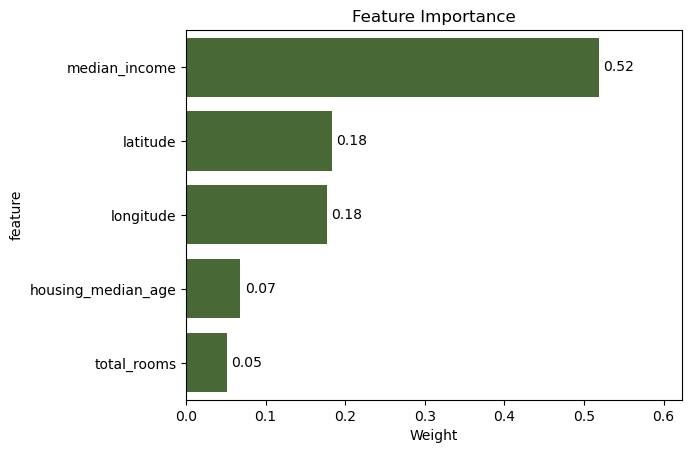

In [107]:
#creating a barplot for feature importance  
color = ["#45722D" if x > 0 else "#C10A0A" for x in importance_df["Weight"]]
graph = sns.barplot(data = importance_df, x = "Weight", y = 'feature', palette= color, hue = "feature", legend = False)
for container in graph.containers:
    graph.bar_label(container, padding = 3, fmt = "%.2f")
graph.margins(x=0.2)
plt.title("Feature Importance")